<a href="https://colab.research.google.com/github/aidenjbrown/Intermediate_Data_Science_CS_28/blob/main/scripts/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. What is your outcome variable(s)? How well does it measure the outcome you are interested? How does it
relate to your expectations?

Our outcome variable is depression score. It measures the outcome we are interested in very well because it is the exact criteria the CDC uses to estimate the prevalance of depression across the population.

2. What are your key explanatory variables?

Our key explanatory variables are race (RIDRETH3 and race_label), income(INDHHIN2/income_label), hours worked last week (OCQ180) and level of education(DMDEDUC2/education_label).

3. What data cleaning did you have to do?

We had to clean the data by replacing any depression symptom indicator that was not between 0 and 3 with a NaN so the scores could only reach a max of 27 (which is the max score for depression screening in the NHANES.)

4. How did you wrangle the data?

We wrangled the data by performing an inner merge on all of the 4 raw datasets by SEQN number. We chose an inner merge because we wanted to have the most data per row possible even if it meant dropping some participants. We also dropped all of the variables we did not need from the raw data by choosing to only keep the subset that we did need.

5. Are you deciding to exclude any observations? If so, why?

We are deciding to exclude any observations that have NaN for depression score since it is our key outcome variable and if a participant does not have that score calculated, that participant is not useful for this data analysis. We also excluded any particpants that did not answer at least 6 out of the 9 depression indicator questions because we wanted to minimize skewing the data to the left due to particpants simply answering fewer questions.

6. Did you have to create any new variables from existing variables? If so, how and why?

We did have to create the depression score variable because it was not calculated for us. So if the answer to each question related to depression symptoms had between a 0 and 3 as a response, we recorded added it to the other responses for the same participant for all the depression symptoms to get a score with the max being 27. We wanted to create this variable so we could determine if certain predictors were associated with depression more broadly rather than invidual symptoms only. Additionally, we createed new variables for any of the encoded categorical variables such as income or race because the enocoded values were hard to interpret without looking at the dataset's codebook.

In [1]:
# Importing the data

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

depression = pd.read_sas('/content/drive/MyDrive/DataScienceXPTFiles/DPQ_J.xpt')
depression.to_csv('/content/drive/MyDrive/DataScienceXPTFiles/Depression_Scores.csv', index=False)

income = pd.read_sas('/content/drive/MyDrive/DataScienceXPTFiles/INQ_J.xpt')
income.to_csv('/content/drive/MyDrive/DataScienceXPTFiles/Income.csv', index=False)

demographics = pd.read_sas('/content/drive/MyDrive/DataScienceXPTFiles/DEMO_J.xpt')
demographics.to_csv('/content/drive/MyDrive/DataScienceXPTFiles/Demographics.csv', index=False)

sleep = pd.read_sas('/content/drive/MyDrive/DataScienceXPTFiles/SLQ_J.xpt')
sleep.to_csv('/content/drive/MyDrive/DataScienceXPTFiles/Sleep.csv', index=False)

occupation = pd.read_sas('/content/drive/MyDrive/DataScienceXPTFiles/OCQ_J.xpt')
occupation.to_csv('/content/drive/MyDrive/DataScienceXPTFiles/Occupation.csv', index=False)


Mounted at /content/drive


In [2]:
# Now we will merge all of the data based on the SEQN number. We are using inner merge to make sure the SEQN exists in both datasets.

merge1 = pd.merge(depression, income, on='SEQN', how = "inner")
print(merge1.shape)
merge2 = pd.merge(merge1, demographics, on='SEQN', how = "inner")
print(merge2.shape)
merge3 = pd.merge(merge2, occupation, on='SEQN', how = "inner")
print(merge3.shape)
df = pd.merge(merge3, sleep, on='SEQN', how = "inner")
print(df.shape)
df

# Now we want to determine what explanatory variables we are going to keep.




(5533, 26)
(5533, 71)
(5533, 80)
(5533, 90)


,SEQN,DPQ010,DPQ020,DPQ030,DPQ040,DPQ050,DPQ060,DPQ070,DPQ080,DPQ090,...,SLQ300,SLQ310,SLD012,SLQ320,SLQ330,SLD013,SLQ030,SLQ040,SLQ050,SLQ120
0,93705.0,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,...,b'23:00',b'07:00',8.0,b'23:00',b'07:00',8.0,2.000000e+00,5.397605e-79,2.0,5.397605e-79
1,93706.0,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,...,b'23:30',b'10:00',10.5,b'00:30',b'12:00',11.5,1.000000e+00,5.397605e-79,2.0,1.000000e+00
2,93708.0,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,...,b'22:30',b'06:30',8.0,b'22:30',b'06:30',8.0,9.000000e+00,5.397605e-79,2.0,2.000000e+00
3,93709.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,b'22:30',b'05:30',7.0,b'22:30',b'05:00',6.5,1.000000e+00,5.397605e-79,2.0,1.000000e+00
4,93711.0,1.000000e+00,5.397605e-79,1.000000e+00,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,...,b'22:00',b'05:00',7.0,b'23:00',b'08:00',9.0,2.000000e+00,1.000000e+00,1.0,3.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5528,102949.0,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,...,b'23:30',b'06:00',6.5,b'23:30',b'06:00',6.5,2.000000e+00,5.397605e-79,2.0,2.000000e+00
5529,102952.0,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,...,b'22:30',b'07:00',8.5,b'22:30',b'07:00',8.5,5.397605e-79,5.397605e-79,2.0,5.397605e-79
5530,102953.0,1.000000e+00,1.000000e+00,5.397605e-79,1.000000e+00,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,...,b'22:00',b'04:00',6.0,b'23:00',b'04:00',5.0,5.397605e-79,1.000000e+00,1.0,2.000000e+00
5531,102954.0,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,...,b'22:00',b'06:00',8.0,b'00:00',b'07:00',7.0,1.000000e+00,5.397605e-79,2.0,1.000000e+00


In [3]:

import numpy as np

# First we are going to replace any response with NaN for the depression indicators that aren't a valid depression score (0-3,) in other words, the responses that did not mention whether
# or how often they were feeling this way. We are ignoring the variable (DPQ100) that asks about the difficulty the problems have causec because it is
# not directly related to depression score and uses a different encoding system.

depression_cols = ["DPQ010", "DPQ020", "DPQ030", "DPQ040", "DPQ050", "DPQ060", "DPQ070", "DPQ080", "DPQ090"]


# Using a Lamda expression here so we can get the data we want (between 0 and 3) for each collumn at a time.
df[depression_cols] = df[depression_cols].apply(lambda x: x.where(x.between(0, 3)))

# Before calculating the depression score, we need to reformat the data so that it is no longer in scientific notation (a quirk of the original .xpt file)

# Operating only on the depression columns.
df[depression_cols] = df[depression_cols].mask(df[depression_cols].abs() < 1e-10)



# Now we want to drop all of the observations of participants who did not answer at least seven of the questions related to depression screening. We first do this by counting how many
# missing responses we have for each participant then using a similar masking strategy. Originally we wanted the participant to answer all the questons, but this got rid of too mnay observations.

count = df[depression_cols].notna().sum(axis=1)
count_mask = count >= 6
df = df[count_mask]

# Creating an aggregated depression score out of 27 estimating the severity of the participant's depression.

df["depression_score"] = df[depression_cols].sum(axis=1)
df

/tmp/ipykernel_23294/1665180811.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["depression_score"] = df[depression_cols].sum(axis=1)


,SEQN,DPQ010,DPQ020,DPQ030,DPQ040,DPQ050,DPQ060,DPQ070,DPQ080,DPQ090,...,SLQ310,SLD012,SLQ320,SLQ330,SLD013,SLQ030,SLQ040,SLQ050,SLQ120,depression_score
6,93713.0,1.0,1.0,2.0,NaN,1.0,1.0,2.0,NaN,NaN,...,b'04:00',5.5,b'23:00',b'06:00',7.0,5.397605e-79,5.397605e-79,1.0,2.0,8.0
33,93758.0,1.0,1.0,3.0,2.0,1.0,NaN,2.0,1.0,NaN,...,b'07:30',5.5,b'02:00',b'07:30',5.5,5.397605e-79,1.000000e+00,1.0,4.0,11.0
35,93760.0,3.0,3.0,3.0,3.0,3.0,1.0,NaN,3.0,NaN,...,b'07:00',8.0,b'23:00',b'07:00',8.0,9.000000e+00,5.397605e-79,2.0,1.0,19.0
53,93782.0,1.0,1.0,2.0,3.0,3.0,NaN,1.0,NaN,NaN,...,b'06:00',8.0,b'00:00',b'07:00',7.0,5.397605e-79,5.397605e-79,2.0,4.0,11.0
74,93815.0,2.0,3.0,3.0,3.0,1.0,2.0,3.0,NaN,NaN,...,b'06:00',8.5,b'22:30',b'06:00',7.5,1.000000e+00,1.000000e+00,2.0,2.0,17.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5487,102878.0,1.0,2.0,1.0,2.0,NaN,NaN,3.0,1.0,1.0,...,b'02:30',8.5,b'18:00',b'02:30',8.5,2.000000e+00,1.000000e+00,1.0,4.0,11.0
5495,102889.0,2.0,2.0,2.0,2.0,1.0,2.0,NaN,NaN,NaN,...,b'08:00',7.0,b'02:00',b'09:00',7.0,3.000000e+00,3.000000e+00,1.0,4.0,11.0
5508,102911.0,3.0,2.0,3.0,3.0,3.0,1.0,NaN,1.0,NaN,...,b'04:30',7.0,b'21:30',b'04:30',7.0,1.000000e+00,1.000000e+00,1.0,2.0,16.0
5522,102935.0,2.0,1.0,3.0,3.0,NaN,1.0,3.0,1.0,NaN,...,b'09:00',8.0,b'00:00',b'10:00',10.0,5.397605e-79,5.397605e-79,1.0,4.0,14.0


In [4]:


# Some of the data is in byte format so, I use the decode comment if it is
df = df.map(lambda x: x.decode() if isinstance(x, bytes) else x)
df.describe()
df

,SEQN,DPQ010,DPQ020,DPQ030,DPQ040,DPQ050,DPQ060,DPQ070,DPQ080,DPQ090,...,SLQ310,SLD012,SLQ320,SLQ330,SLD013,SLQ030,SLQ040,SLQ050,SLQ120,depression_score
6,93713.0,1.0,1.0,2.0,NaN,1.0,1.0,2.0,NaN,NaN,...,04:00,5.5,23:00,06:00,7.0,5.397605e-79,5.397605e-79,1.0,2.0,8.0
33,93758.0,1.0,1.0,3.0,2.0,1.0,NaN,2.0,1.0,NaN,...,07:30,5.5,02:00,07:30,5.5,5.397605e-79,1.000000e+00,1.0,4.0,11.0
35,93760.0,3.0,3.0,3.0,3.0,3.0,1.0,NaN,3.0,NaN,...,07:00,8.0,23:00,07:00,8.0,9.000000e+00,5.397605e-79,2.0,1.0,19.0
53,93782.0,1.0,1.0,2.0,3.0,3.0,NaN,1.0,NaN,NaN,...,06:00,8.0,00:00,07:00,7.0,5.397605e-79,5.397605e-79,2.0,4.0,11.0
74,93815.0,2.0,3.0,3.0,3.0,1.0,2.0,3.0,NaN,NaN,...,06:00,8.5,22:30,06:00,7.5,1.000000e+00,1.000000e+00,2.0,2.0,17.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5487,102878.0,1.0,2.0,1.0,2.0,NaN,NaN,3.0,1.0,1.0,...,02:30,8.5,18:00,02:30,8.5,2.000000e+00,1.000000e+00,1.0,4.0,11.0
5495,102889.0,2.0,2.0,2.0,2.0,1.0,2.0,NaN,NaN,NaN,...,08:00,7.0,02:00,09:00,7.0,3.000000e+00,3.000000e+00,1.0,4.0,11.0
5508,102911.0,3.0,2.0,3.0,3.0,3.0,1.0,NaN,1.0,NaN,...,04:30,7.0,21:30,04:30,7.0,1.000000e+00,1.000000e+00,1.0,2.0,16.0
5522,102935.0,2.0,1.0,3.0,3.0,NaN,1.0,3.0,1.0,NaN,...,09:00,8.0,00:00,10:00,10.0,5.397605e-79,5.397605e-79,1.0,4.0,14.0


In [5]:
# Now it is time to drop all of the variables we don't need

columns_we_want = ["SEQN", "DPQ010", "DPQ020", "DPQ030", "DPQ040", "DPQ050", "DPQ060", "DPQ070", "DPQ080", "DPQ090", "SLD012", "SLD013", "RIAGENDR", "RIDRETH3", "INDHHIN2", "INDFMPIR", "DMDEDUC2", "DMDEDUC3", "OCQ180", "depression_score"]
df = df[columns_we_want]
df

,SEQN,DPQ010,DPQ020,DPQ030,DPQ040,DPQ050,DPQ060,DPQ070,DPQ080,DPQ090,SLD012,SLD013,RIAGENDR,RIDRETH3,INDHHIN2,INDFMPIR,DMDEDUC2,DMDEDUC3,OCQ180,depression_score
6,93713.0,1.0,1.0,2.0,NaN,1.0,1.0,2.0,NaN,NaN,5.5,7.0,1.0,3.0,6.0,2.65,3.0,NaN,NaN,8.0
33,93758.0,1.0,1.0,3.0,2.0,1.0,NaN,2.0,1.0,NaN,5.5,5.5,2.0,3.0,3.0,0.75,1.0,NaN,NaN,11.0
35,93760.0,3.0,3.0,3.0,3.0,3.0,1.0,NaN,3.0,NaN,8.0,8.0,2.0,1.0,NaN,NaN,1.0,NaN,25.0,19.0
53,93782.0,1.0,1.0,2.0,3.0,3.0,NaN,1.0,NaN,NaN,8.0,7.0,2.0,4.0,14.0,4.65,4.0,NaN,40.0,11.0
74,93815.0,2.0,3.0,3.0,3.0,1.0,2.0,3.0,NaN,NaN,8.5,7.5,2.0,7.0,4.0,1.12,4.0,NaN,NaN,17.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5487,102878.0,1.0,2.0,1.0,2.0,NaN,NaN,3.0,1.0,1.0,8.5,8.5,1.0,1.0,10.0,4.19,2.0,NaN,40.0,11.0
5495,102889.0,2.0,2.0,2.0,2.0,1.0,2.0,NaN,NaN,NaN,7.0,7.0,1.0,1.0,1.0,0.21,4.0,NaN,41.0,11.0
5508,102911.0,3.0,2.0,3.0,3.0,3.0,1.0,NaN,1.0,NaN,7.0,7.0,2.0,7.0,4.0,1.17,3.0,NaN,NaN,16.0
5522,102935.0,2.0,1.0,3.0,3.0,NaN,1.0,3.0,1.0,NaN,8.0,10.0,2.0,3.0,14.0,0.85,5.0,NaN,NaN,14.0


/tmp/ipykernel_23294/250765421.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["race_label"]= df["RIDRETH3"].map(race_map)


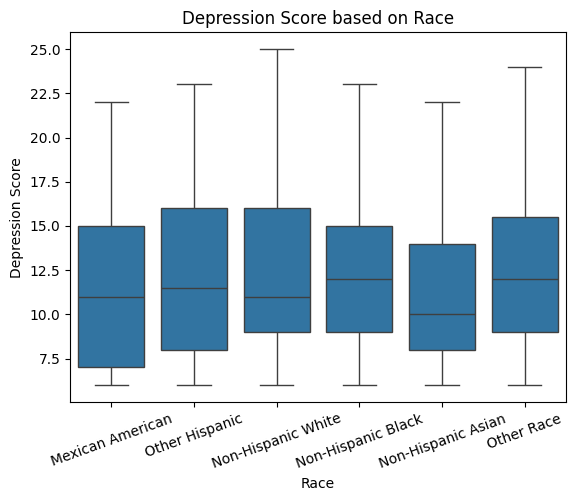

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt


# First we want to work on comparing race vs depression score, so we map the actual categorical variables onto the encoded variables for race.

race_map = {1: "Mexican American",
            2: "Other Hispanic",
            3: "Non-Hispanic White",
            4: "Non-Hispanic Black",
            6: "Non-Hispanic Asian",
            7: "Other Race"
            }
df["race_label"]= df["RIDRETH3"].map(race_map)


# Before we make the box plot, we have to put the race categories in the order the dataset did.


order = ["Mexican American",  "Other Hispanic", "Non-Hispanic White", "Non-Hispanic Black", "Non-Hispanic Asian", "Other Race"]

# Making a box plot comparing depression score based on race.

sns.boxplot(x="race_label", y="depression_score", data=df, order = order)

plt.xlabel("Race")
plt.ylabel("Depression Score")
plt.title("Depression Score based on Race")

plt.xticks(rotation=20)

plt.show()



It appears that while most races have a median depression score of approximately 11, asians have a median depression score of about 10, a whole point less than the average median score across races. Additionally Other Hispanics have a much wider distribution of depression scores between the first and third quartile compared to any of the other races. Otherwise, the distriubtion of depression scores is relatively uniform among all races.

/tmp/ipykernel_23294/1118766954.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["education_label"]= df["DMDEDUC2"].map(education_map)


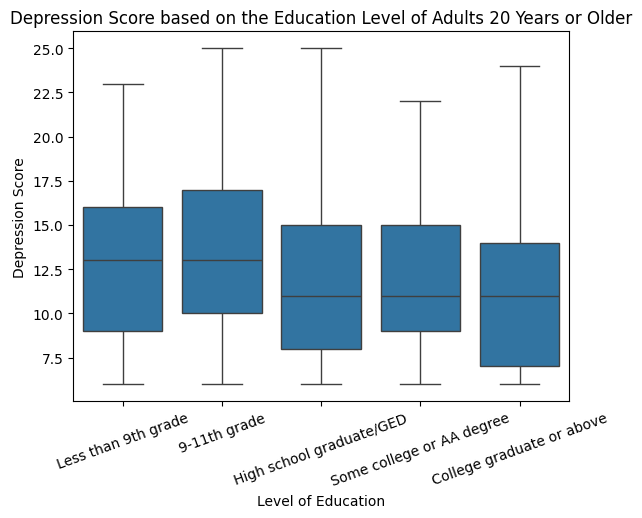

In [7]:
# Next we want to work on comparing education level of adults vs depression score, so now we map the actual categorical variables onto the encoded variables for education.

education_map = {
            1: "Less than 9th grade",
            2: "9-11th grade",
            3: "High school graduate/GED",
            4: "Some college or AA degree",
            5: "College graduate or above"
            }
df["education_label"]= df["DMDEDUC2"].map(education_map)


# Before we make the box plot, we put levels of education in order of least to most education.


order = ["Less than 9th grade",  "9-11th grade", "High school graduate/GED", "Some college or AA degree", "College graduate or above"]

# Making a box plot comparing depression score based to race.

sns.boxplot(x="education_label", y="depression_score", data=df, order = order)

plt.xlabel("Level of Education")
plt.ylabel("Depression Score")
plt.title("Depression Score based on the Education Level of Adults 20 Years or Older")


plt.xticks(rotation=20)

plt.show()

It appears that those who have graduated high school (or the equivalent) or have recieved a higher level of education have a substantially lower median depression score than those who did not reach this level of education. While the mean depression score of those with less education than the equivalent of a high school degree is about 13, it is only about 10.5 for those who have recieved the equivalent of a high school education or higher.

/tmp/ipykernel_23294/504860474.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["income_label"]= df["INDHHIN2"].map(income_map)


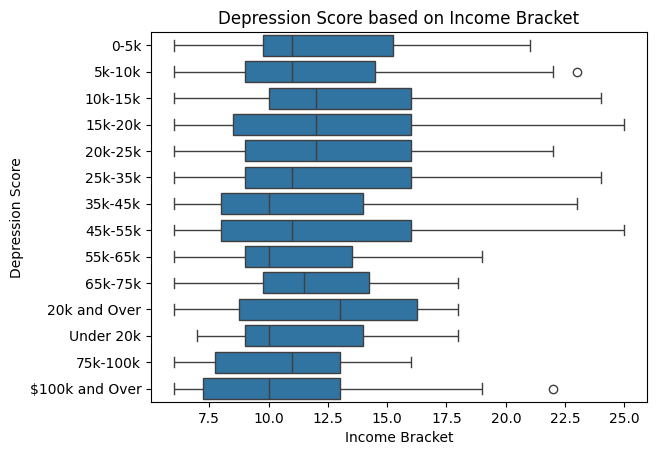

In [8]:
# Now we want to work on comparing participants' income level to to their depression score, so lets map the actual categorical variables onto the encoded variables for income.

income_map = {
            1: "0-5k",
            2: "5k-10k",
            3: "10k-15k",
            4: "15k-20k",
            5: "20k-25k",
            6: "25k-35k",
            7: "35k-45k",
            8: "45k-55k",
            9: "55k-65k",
            10: "65k-75k",
            12: "20k and Over",
            13: "Under 20k",
            14: "75k-100k",
            15: "$100k and Over"
            }
df["income_label"]= df["INDHHIN2"].map(income_map)


# Before we make the box plot, we have to put levels of income in the order the CDC put them in (more or less in the order of least to most inocome.)


order = [
          "0-5k",
          "5k-10k",
          "10k-15k",
          "15k-20k",
          "20k-25k",
          "25k-35k",
          "35k-45k",
          "45k-55k",
          "55k-65k",
          "65k-75k",
          "20k and Over",
          "Under 20k",
          "75k-100k",
          "$100k and Over"
]

# Making a box plot comparing depression score based on race (but making it horizontal for readablility).

sns.boxplot(x="depression_score", y="income_label", data=df, order = order)

plt.xlabel("Income Bracket")
plt.ylabel("Depression Score")
plt.title("Depression Score based on Income Bracket")


plt.tight_layout
plt.show()

It appears that those whose household makes 0 to 4,999, 45,000 to 54,999, 65,000 to 74,999 and under 20,000 dollars have a substantially lower median depression score than those who have any other quantity of money. What is less suprising is that the median depression score for those whose household makes 20,000 dollars and over is much smaller than those who make under 20,000 dollars with the former and latter levels having median depression scores of approximately 10.5 and 13 respectively.

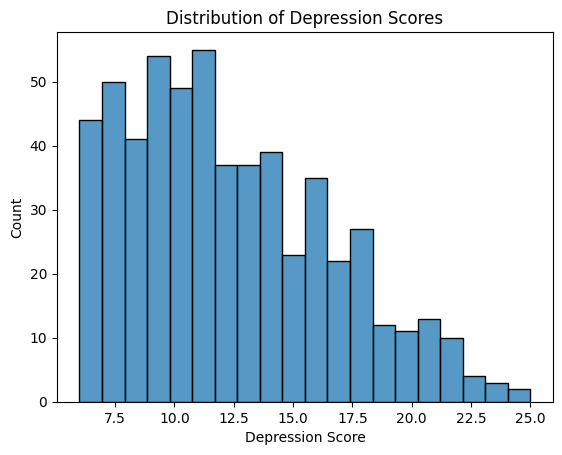

In [9]:
# Making a histogram of depression scores to determine which scores are most common across all participants

sns.histplot(data=df, x="depression_score", bins=20)

plt.xlabel("Depression Score")
plt.ylabel("Count")
plt.title("Distribution of Depression Scores")



plt.show()

Based on the histogram, the most common depression score is approximately 11.25 with a count of about 57 observations. Additionally, the histogram is skewed right which indicates that there is an observagble minority of participants with a depression score greter than or equal to 12.5 (as there is no observed score above 25).

/tmp/ipykernel_23294/856251852.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['OCQ180'] = df['OCQ180'].replace([77777, 99999,'.'], np.nan)


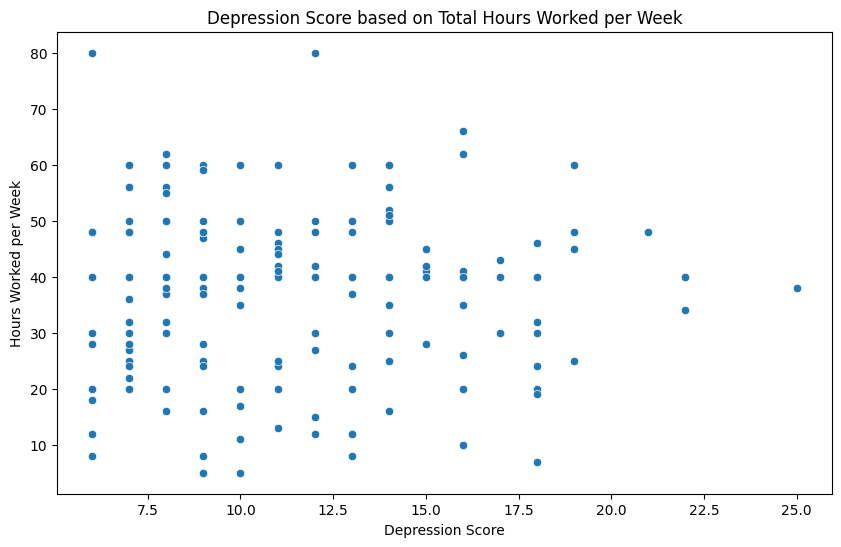

,SEQN,DPQ010,DPQ020,DPQ030,DPQ040,DPQ050,DPQ060,DPQ070,DPQ080,DPQ090,...,RIDRETH3,INDHHIN2,INDFMPIR,DMDEDUC2,DMDEDUC3,OCQ180,depression_score,race_label,education_label,income_label
6,93713.0,1.0,1.0,2.0,NaN,1.0,1.0,2.0,NaN,NaN,...,3.0,6.0,2.65,3.0,NaN,NaN,8.0,Non-Hispanic White,High school graduate/GED,25k-35k
33,93758.0,1.0,1.0,3.0,2.0,1.0,NaN,2.0,1.0,NaN,...,3.0,3.0,0.75,1.0,NaN,NaN,11.0,Non-Hispanic White,Less than 9th grade,10k-15k
35,93760.0,3.0,3.0,3.0,3.0,3.0,1.0,NaN,3.0,NaN,...,1.0,NaN,NaN,1.0,NaN,25.0,19.0,Mexican American,Less than 9th grade,NaN
53,93782.0,1.0,1.0,2.0,3.0,3.0,NaN,1.0,NaN,NaN,...,4.0,14.0,4.65,4.0,NaN,40.0,11.0,Non-Hispanic Black,Some college or AA degree,75k-100k
74,93815.0,2.0,3.0,3.0,3.0,1.0,2.0,3.0,NaN,NaN,...,7.0,4.0,1.12,4.0,NaN,NaN,17.0,Other Race,Some college or AA degree,15k-20k
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5487,102878.0,1.0,2.0,1.0,2.0,NaN,NaN,3.0,1.0,1.0,...,1.0,10.0,4.19,2.0,NaN,40.0,11.0,Mexican American,9-11th grade,65k-75k
5495,102889.0,2.0,2.0,2.0,2.0,1.0,2.0,NaN,NaN,NaN,...,1.0,1.0,0.21,4.0,NaN,41.0,11.0,Mexican American,Some college or AA degree,0-5k
5508,102911.0,3.0,2.0,3.0,3.0,3.0,1.0,NaN,1.0,NaN,...,7.0,4.0,1.17,3.0,NaN,NaN,16.0,Other Race,High school graduate/GED,15k-20k
5522,102935.0,2.0,1.0,3.0,3.0,NaN,1.0,3.0,1.0,NaN,...,3.0,14.0,0.85,5.0,NaN,NaN,14.0,Non-Hispanic White,College graduate or above,75k-100k


In [10]:
# Now We are going to compare Depression Scores by occupation:

df['OCQ180'] = df['OCQ180'].replace([77777, 99999,'.'], np.nan)
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x="depression_score", y="OCQ180", ax=ax)

plt.xlabel("Depression Score")
plt.ylabel("Hours Worked per Week")
plt.title("Depression Score based on Total Hours Worked per Week")

plt.show()
df

There is no clear relationship between depression score based on hours worked per week, although there does seem to be a larger cluster of scores around 6.5 go 18 which is likely a result of few participants answering all questions (otherwise the cluster would likely be shifted right.)